In [11]:
# Базовые библиотеки
import os
import sys
import math
import time
import random
from typing import Tuple, Dict, List
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import datasets, transforms

from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)


print("python:", sys.version)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

python: 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]
torch: 2.11.0+cu130
torchvision: 0.26.0+cu130


In [12]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

ROOT = Path("..").resolve()
ARTIFACT_DIR = ROOT / "artifacts"

FAST_MODE = False   # переключите на True для частичного датасета и более быстрого обучения

EPOCHS = 5 if FAST_MODE else 5
EPOCHS_HEAD = 3 if FAST_MODE else 3
EPOCHS_FT   = 3 if FAST_MODE else 3

Device: cuda


In [13]:
from src.data import load_datasets, get_transforms

train_tf, eval_tf = get_transforms()
train_ds, val_ds, test_ds = load_datasets()
class_names = train_ds.classes

In [14]:
BATCH_SIZE_CNN = 128
BATCH_SIZE_RN = 64

def make_loaders_model(
    ds_train,
    ds_val,
    ds_test,
    batch_size: int,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    rng = np.random.RandomState(seed)
    indices = np.arange(len(ds_train))
    rng.shuffle(indices)
    
    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(1000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(500, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(500, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=6, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=6, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=6, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader_cnn, val_loader_cnn, test_loader_cnn = make_loaders_model(
    train_ds, val_ds, test_ds, batch_size=BATCH_SIZE_CNN,
)

x, y = next(iter(train_loader_cnn))
print("CNN - x:", x.shape, x.dtype)
print("CNN - y:", y.shape, y.dtype)


train_loader_resnet, val_loader_resnet, test_loader_resnet = make_loaders_model(
    train_ds, val_ds, test_ds, batch_size=BATCH_SIZE_RN,
)

x, y = next(iter(train_loader_resnet))
print("ResNet - x:", x.shape, x.dtype)
print("ResNet - y:", y.shape, y.dtype)

CNN - x: torch.Size([128, 3, 224, 224]) torch.float32
CNN - y: torch.Size([128]) torch.int64
ResNet - x: torch.Size([64, 3, 224, 224]) torch.float32
ResNet - y: torch.Size([64]) torch.int64


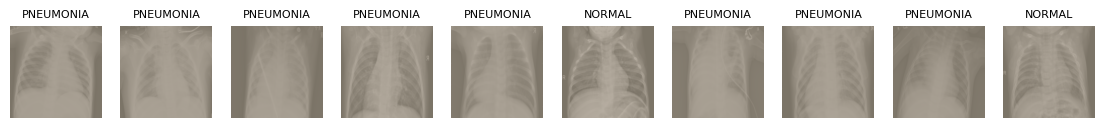

In [15]:
DATASET_MEAN = (0.485, 0.456, 0.406)
DATASET_STD  = (0.229, 0.224, 0.225)

def denorm_dataset(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(DATASET_MEAN).view(3, 1, 1)
    std = torch.tensor(DATASET_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10, save_path=None) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_dataset(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")

    if save_path:
        plt.savefig(save_path)
    plt.show()
    plt.close()

show_images(train_loader_cnn, n=10, save_path=ARTIFACT_DIR)

In [16]:
INPUT_DIM = 224 * 224 * 3
NUM_CLASSES = len(class_names)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# модель CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int=2):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model_cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(model_cnn)
print("Trainable params:", count_params(model_cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
Trainable params: 101634


In [17]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


# @torch.no_grad()
# def evaluate(model, loader, criterion):
#     model.eval()
#     total_loss, total_correct, total_seen = 0.0, 0, 0
#     tp, fn = 0, 0
#     for x, y in loader:
#         x, y = x.to(DEVICE), y.to(DEVICE)
#         logits = model(x)
#         loss = criterion(logits, y)

#         if not torch.isfinite(loss):
#             return float("nan"), float("nan")
        
#         preds = torch.argmax(logits, dim=1)
#         bs = y.size(0)
#         total_loss += loss.item() * bs
#         total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
#         total_seen += bs
#         tp += ((preds == 1) & (y == 1)).sum().item()
#         fn += ((preds == 0) & (y == 1)).sum().item()
    
#     acc = total_correct / total_seen
#     loss_avg = total_loss / total_seen
#     recall = tp / (tp + fn + 1e-8)

#     return loss_avg, acc, recall


# def compute_metrics(y_true, y_pred, y_prob):
#     return {
#         "acc": accuracy_score(y_true, y_pred),
#         "precision": precision_score(y_true, y_pred, zero_division=0),
#         "recall": recall_score(y_true, y_pred, zero_division=0),
#         "f1": f1_score(y_true, y_pred, zero_division=0),
#         "roc_auc": roc_auc_score(y_true, y_prob),
#     }


# def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
#     history = {"optimizer": optimizer, 
#                "criterion": criterion, 
#                "train_loss": [], 
#                "train_acc": [], 
#                "val_loss": [], 
#                "val_acc": [], 
#                "recall": [],
#                "precision": [],
#                "f1": [],
#                "roc_auc": [],
#               }

#     for epoch in range(1, epochs + 1):
#         t0 = time.time()
#         tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
#         va_loss, va_acc, va_recall = evaluate(model, val_loader, criterion)
#         res = evaluate(model, val_loader, criterion)
#         history["train_loss"].append(tr_loss)
#         history["train_acc"].append(tr_acc)
#         history["val_loss"].append(va_loss)
#         history["val_acc"].append(va_acc)
#         history["recall"].append(va_recall)

#         dt = time.time() - t0
#         if verbose:
#             print(
#                 f"Epoch {epoch:02d}/{epochs} | "
#                 f"train loss {tr_loss:.4f}, acc {tr_acc:.4f} | "
#                 f"val loss {va_loss:.4f}, acc {va_acc:.4f}, recall {va_recall:.3f} | "
#                 f"{dt:.1f}s"
#             )

#         if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
#             print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
#             break

#     return history

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_seen = 0

    all_targets = []
    all_preds = []
    all_probs = []

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), None, None, None

        probs = torch.softmax(logits, dim=1)[:, 1]   # вероятность класса 1
        preds = torch.argmax(logits, dim=1)

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_seen += bs

        all_targets.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    loss_avg = total_loss / total_seen

    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    return loss_avg, y_true, y_pred, y_prob

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred),
    }

@torch.no_grad()
def plot_confusion_matrix(hist, descr="Best Model"):
    print("Epoch:", hist['epoch'])
    cm = hist['cm']
    fig, ax = plt.subplots()
    im = ax.imshow(cm)
    label_names = ["NORMAL", "PNEUMONIA"]
    ax.set_xticks(range(len(label_names)))
    ax.set_yticks(range(len(label_names)))
    ax.set_xticklabels(label_names, ha="right")
    ax.set_yticklabels(label_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(descr)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    # plt.savefig(ARTIFACTS_DIR / "confusion_matrix.png")
    plt.show()
    
def fit(model, train_loader, val_loader, optimizer, criterion,
        epochs=10, verbose=True):

    print("Trainable params:", count_params(model))
    
    history = []
    best_f1 = -1.0
    best_epoch_metrics = {}

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # train
        tr_loss, tr_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        # val
        va_loss, y_true, y_pred, y_prob = evaluate(
            model,
            val_loader,
            criterion
        )

        if y_true is None:
            print("NaN/Inf during validation")
            break

        metrics = compute_metrics(y_true, y_pred, y_prob)
        
        row = {
            "epoch": epoch,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "val_loss": va_loss,
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob, 
            **metrics
        }

        history.append(row)

        # save best model
        if metrics["f1"] > best_f1:
            best_epoch_metrics = row
            best_f1 = metrics["f1"]
            # torch.save(model.state_dict(), "best_model.pth")


        dt = time.time() - t0

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.4f} | "
                f"val loss {va_loss:.4f}, "
                f"acc {metrics['acc']:.4f}, "
                f"recall {metrics['recall']:.4f}, "
                f"f1 {metrics['f1']:.4f}, "
                f"auc {metrics['roc_auc']:.4f} | "
                f"{dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf detected. Stop training.")
            break

    #вывод confusion matrix лучшей эпохи обучения
    plot_confusion_matrix(best_epoch_metrics)
    
    history = pd.DataFrame(history)

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "", save_name: str = None) -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["acc"], label="train acc")
    plt.xlabel("epoch")
    # plt.ylabel("loss")
    plt.title(title + " | train")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.plot(epochs, hist["acc"], label="val acc")
    plt.plot(epochs, hist["recall"], label="recall")
    plt.xlabel("epoch")
    # plt.ylabel("accuracy")
    plt.title(title + " | val")
    plt.grid(True)
    plt.legend()
    if save_name:
        plt.savefig(ARTIFACT_DIR / save_name)
    plt.show()

In [18]:
# criterion = nn.CrossEntropyLoss()
class_weights = torch.tensor([1.0, 1.8])
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

def run_experiment(exp_id: str, name: str, model: nn.Module, optimizer=None, criterion=criterion,
                       lr: float = 1e-4, weight_decay: float = 1e-4, epochs: int = 5):
    model = model.to(DEVICE)
    # optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if not optimizer:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    train_loader, val_loader, _ = make_loaders_model(train_ds, val_ds, test_ds, batch_size=BATCH_SIZE_CNN)
        
    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model_name": name, "model": model, "history": hist, "best_val_acc": best_val_acc}

In [19]:
optimizer_common = torch.optim.AdamW(
            model_cnn.parameters(),
            lr=1e-4,
            weight_decay=1e-4
        )


# res_cnn = run_experiment("C1", "CNN", SimpleCNN(NUM_CLASSES), epochs=EPOCHS)
# plot_history(res_cnn["history"], title=res_cnn["model_name"])
# print(res_cnn["history"])

Trainable params: 101634
Epoch 01/5 | train loss 0.4477, acc 0.7429 | val loss 0.7710, acc 0.6250, recall 1.0000, f1 0.7692, auc 0.3731 | 52.0s
Epoch 02/5 | train loss 0.4471, acc 0.7429 | val loss 0.7688, acc 0.6250, recall 1.0000, f1 0.7692, auc 0.3857 | 51.7s
Epoch 03/5 | train loss 0.4456, acc 0.7429 | val loss 0.7647, acc 0.6250, recall 1.0000, f1 0.7692, auc 0.4171 | 51.4s
Epoch 04/5 | train loss 0.4425, acc 0.7429 | val loss 0.7625, acc 0.6250, recall 1.0000, f1 0.7692, auc 0.4628 | 50.3s
Epoch 05/5 | train loss 0.4406, acc 0.7429 | val loss 0.7617, acc 0.6250, recall 1.0000, f1 0.7692, auc 0.5128 | 50.4s
Epoch: 1


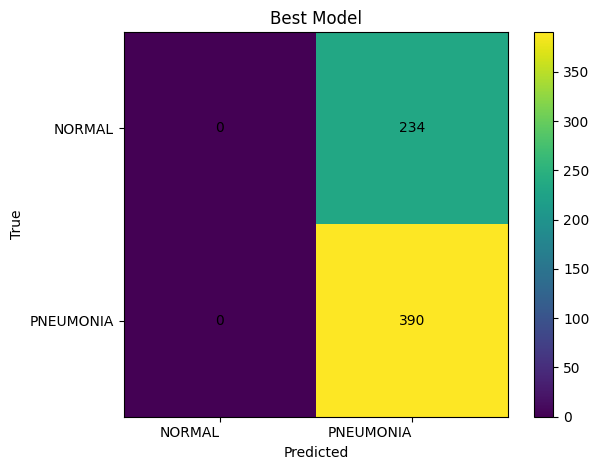

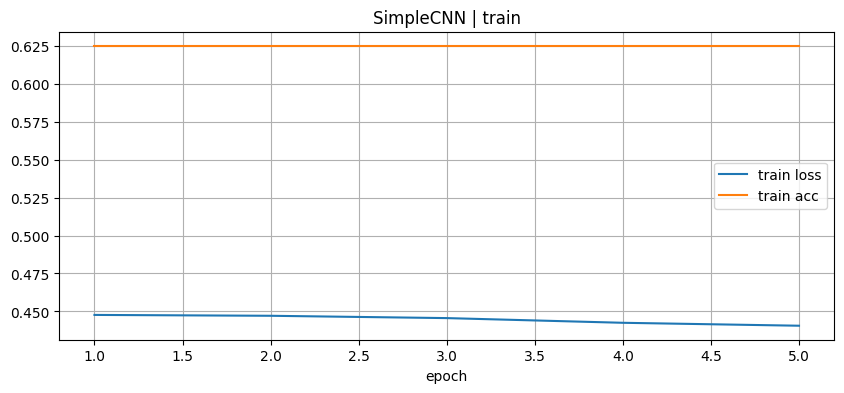

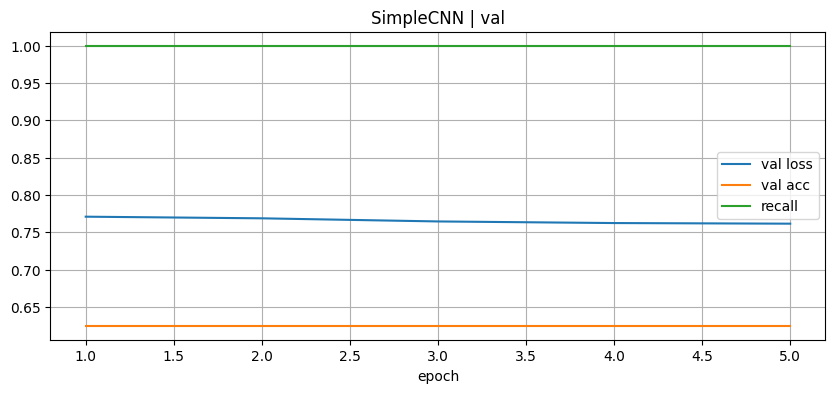

In [21]:
hist_CNN = fit(model_cnn, train_loader_cnn, test_loader_cnn, optimizer_common, criterion, epochs=5, verbose=True)
plot_history(hist_CNN, title="SimpleCNN", save_name="CNN_model")

In [22]:
def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [23]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# создание модели ResNet
def build_resnet18(num_classes: int, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model_resnet18 = build_resnet18(num_classes=NUM_CLASSES, weights=weights).to(DEVICE)
print(model_resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Trainable params: 11177538
Epoch 01/5 | train loss 0.9869, acc 0.2889 | val loss 0.8299, acc 0.3910, recall 0.1103, f1 0.1845, auc 0.4784 | 52.2s
Epoch 02/5 | train loss 0.9896, acc 0.2889 | val loss 0.8418, acc 0.3926, recall 0.0513, f1 0.0955, auc 0.6200 | 51.3s
Epoch 03/5 | train loss 0.9876, acc 0.2872 | val loss 0.8495, acc 0.3942, recall 0.0513, f1 0.0957, auc 0.6151 | 51.5s
Epoch 04/5 | train loss 0.9865, acc 0.2937 | val loss 0.8406, acc 0.3942, recall 0.0513, f1 0.0957, auc 0.6238 | 51.5s
Epoch 05/5 | train loss 0.9845, acc 0.2916 | val loss 0.8492, acc 0.3926, recall 0.0487, f1 0.0911, auc 0.6200 | 49.1s
Epoch: 1


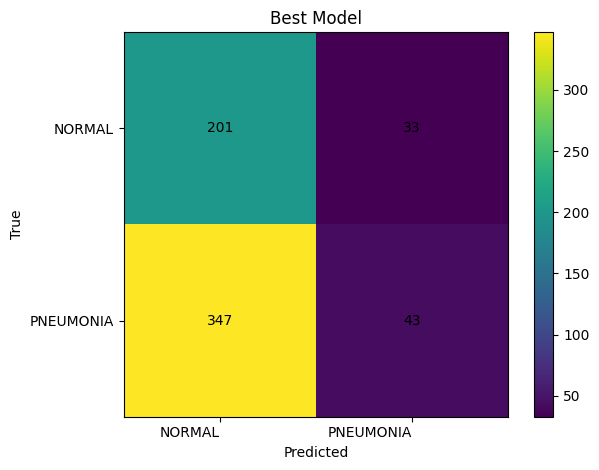

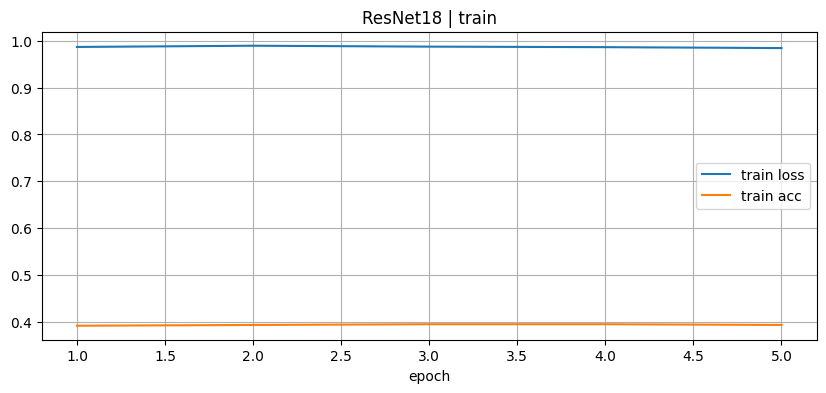

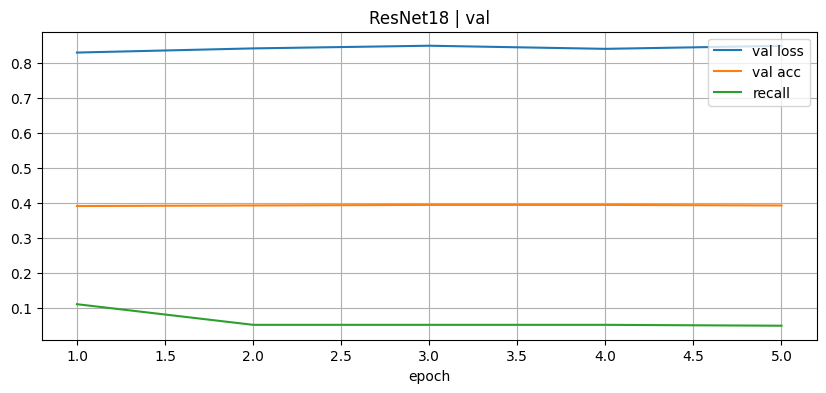

In [24]:
hist_resnet = fit(model_resnet18, train_loader_resnet, test_loader_resnet, optimizer_common, criterion, epochs=5, verbose=True)
plot_history(hist_resnet, title="ResNet18", save_name="ResNet18_model")

Trainable params (head-only): 1026

Phase 1: head-only training
Trainable params: 1026
Epoch 01/5 | train loss 0.2902, acc 0.8834 | val loss 0.7587, acc 0.6843, recall 1.0000, f1 0.7984, auc 0.9458 | 45.2s
Epoch 02/5 | train loss 0.1712, acc 0.9325 | val loss 0.4454, acc 0.7981, recall 0.9846, f1 0.8591, auc 0.9476 | 45.9s
Epoch 03/5 | train loss 0.1571, acc 0.9415 | val loss 0.5533, acc 0.7628, recall 0.9923, f1 0.8395, auc 0.9488 | 44.9s
Epoch 04/5 | train loss 0.1453, acc 0.9431 | val loss 0.4781, acc 0.7965, recall 0.9846, f1 0.8581, auc 0.9495 | 44.7s
Epoch 05/5 | train loss 0.1337, acc 0.9459 | val loss 0.4596, acc 0.8077, recall 0.9846, f1 0.8649, auc 0.9487 | 44.6s
Epoch: 5


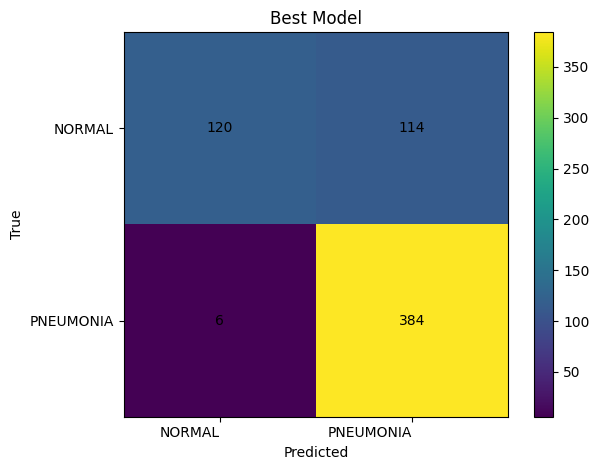

Trainable params: 1026
Epoch 01/5 | train loss 0.1343, acc 0.9425 | val loss 0.4146, acc 0.8365, recall 0.9744, f1 0.8817, auc 0.9494 | 44.6s
Epoch 02/5 | train loss 0.1285, acc 0.9492 | val loss 0.5757, acc 0.7997, recall 0.9897, f1 0.8606, auc 0.9460 | 44.8s
Epoch 03/5 | train loss 0.1273, acc 0.9484 | val loss 0.6079, acc 0.8029, recall 0.9897, f1 0.8626, auc 0.9442 | 44.8s
Epoch 04/5 | train loss 0.1093, acc 0.9590 | val loss 0.4490, acc 0.8446, recall 0.9795, f1 0.8873, auc 0.9410 | 44.6s
Epoch 05/5 | train loss 0.1176, acc 0.9536 | val loss 0.4602, acc 0.8446, recall 0.9795, f1 0.8873, auc 0.9440 | 45.0s
Epoch: 4


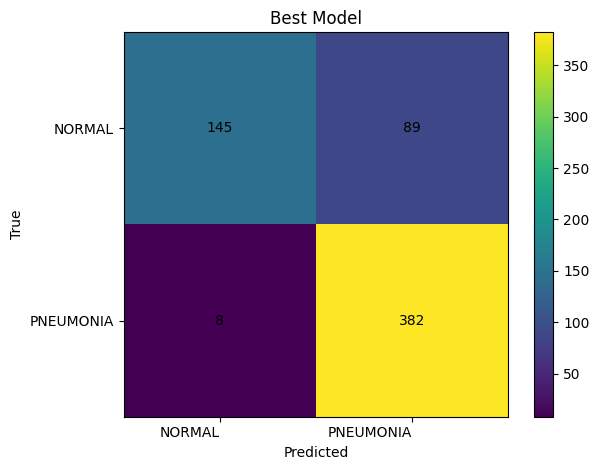

Trainable params: 1026
Epoch 01/5 | train loss 0.0938, acc 0.9624 | val loss 0.6161, acc 0.8093, recall 0.9897, f1 0.8664, auc 0.9426 | 44.6s
Epoch 02/5 | train loss 0.0930, acc 0.9622 | val loss 0.6387, acc 0.7997, recall 0.9897, f1 0.8606, auc 0.9416 | 45.6s
Epoch 03/5 | train loss 0.0941, acc 0.9618 | val loss 0.5871, acc 0.8109, recall 0.9897, f1 0.8674, auc 0.9406 | 43.3s
Epoch 04/5 | train loss 0.0940, acc 0.9638 | val loss 0.5342, acc 0.8253, recall 0.9846, f1 0.8757, auc 0.9429 | 44.2s
Epoch 05/5 | train loss 0.0910, acc 0.9645 | val loss 0.5507, acc 0.8221, recall 0.9846, f1 0.8737, auc 0.9411 | 45.8s
Epoch: 4


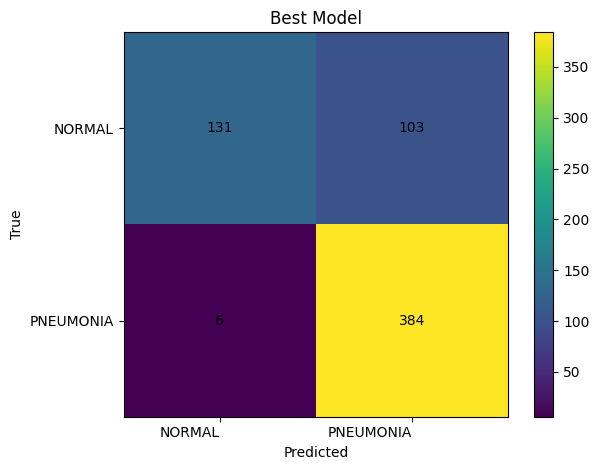

In [25]:
criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=NUM_CLASSES, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.AdamW(model_head.fc.parameters(), lr=1e-3)
optimizer_head2 = torch.optim.AdamW(model_head.fc.parameters(), lr=3e-3)
optimizer_head3 = torch.optim.AdamW(model_head.fc.parameters(), lr=3e-4)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_head, train_loader_resnet, test_loader_resnet, optimizer_head, criterion, epochs=5, verbose=True)
hist_head = fit(model_head, train_loader_resnet, test_loader_resnet, optimizer_head2, criterion, epochs=5, verbose=True)
hist_head = fit(model_head, train_loader_resnet, test_loader_resnet, optimizer_head3, criterion, epochs=5, verbose=True)
# plot_history(hist_head, title="ResNet18 | head-only")

Trainable params (layer4+fc): 10494466

Phase 2: fine-tuning layer4 + fc
Trainable params: 10494466
Epoch 01/5 | train loss 0.0838, acc 0.9705 | val loss 1.5224, acc 0.7404, recall 0.9949, f1 0.8273, auc 0.9226 | 49.9s
Epoch 02/5 | train loss 0.0382, acc 0.9868 | val loss 1.4729, acc 0.7756, recall 0.9974, f1 0.8475, auc 0.9149 | 50.6s
Epoch 03/5 | train loss 0.0095, acc 0.9962 | val loss 1.4328, acc 0.8061, recall 0.9923, f1 0.8648, auc 0.9273 | 49.1s
Epoch 04/5 | train loss 0.0109, acc 0.9962 | val loss 1.3097, acc 0.8381, recall 0.9923, f1 0.8846, auc 0.9404 | 46.9s
Epoch 05/5 | train loss 0.0034, acc 0.9988 | val loss 1.6144, acc 0.8205, recall 0.9974, f1 0.8742, auc 0.9263 | 47.2s
Epoch: 4


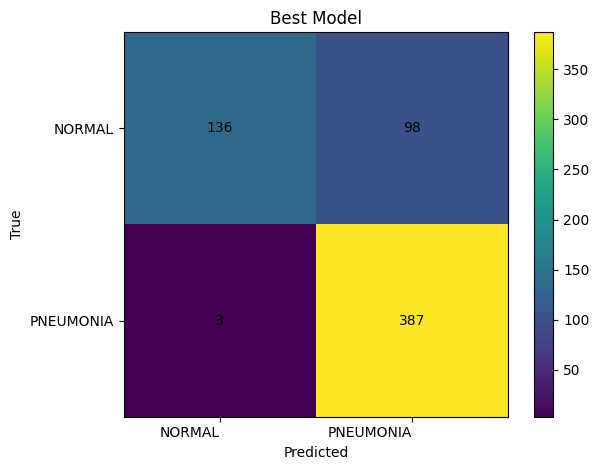

Trainable params: 10494466
Epoch 01/5 | train loss 0.0040, acc 0.9992 | val loss 1.6413, acc 0.8205, recall 0.9974, f1 0.8742, auc 0.9195 | 51.5s
Epoch 02/5 | train loss 0.0008, acc 1.0000 | val loss 1.5079, acc 0.8349, recall 0.9974, f1 0.8831, auc 0.9297 | 49.5s
Epoch 03/5 | train loss 0.0012, acc 0.9996 | val loss 1.6793, acc 0.8173, recall 0.9974, f1 0.8722, auc 0.9192 | 47.9s
Epoch 04/5 | train loss 0.0006, acc 1.0000 | val loss 1.6873, acc 0.8173, recall 0.9949, f1 0.8719, auc 0.9197 | 50.9s
Epoch 05/5 | train loss 0.0007, acc 0.9998 | val loss 1.6934, acc 0.8205, recall 0.9974, f1 0.8742, auc 0.9183 | 44.9s
Epoch: 2


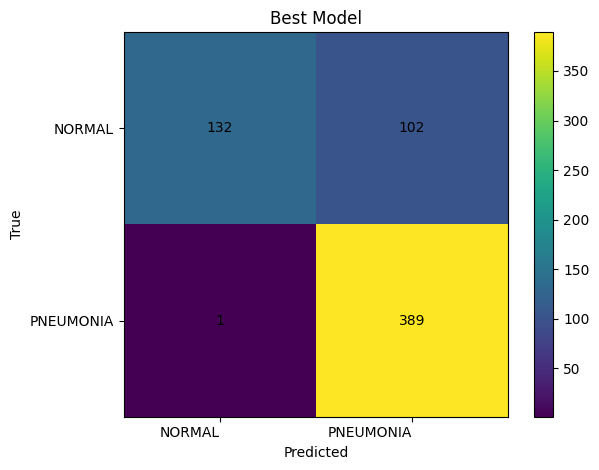

Trainable params: 10494466
Epoch 01/5 | train loss 0.0709, acc 0.9810 | val loss 1.7881, acc 0.7949, recall 0.9821, f1 0.8568, auc 0.9249 | 45.2s
Epoch 02/5 | train loss 0.0455, acc 0.9866 | val loss 2.1769, acc 0.7356, recall 1.0000, f1 0.8254, auc 0.9439 | 44.6s
Epoch 03/5 | train loss 0.0238, acc 0.9937 | val loss 1.3833, acc 0.8109, recall 1.0000, f1 0.8686, auc 0.9587 | 44.1s
Epoch 04/5 | train loss 0.0149, acc 0.9942 | val loss 2.4739, acc 0.7468, recall 1.0000, f1 0.8316, auc 0.9003 | 43.2s
Epoch 05/5 | train loss 0.0185, acc 0.9937 | val loss 2.4925, acc 0.7372, recall 1.0000, f1 0.8263, auc 0.9132 | 43.4s
Epoch: 3


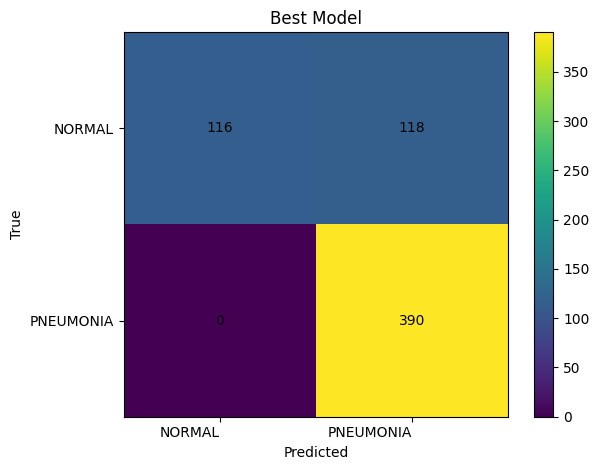

In [26]:
# размораживаем layer4 и fc
set_requires_grad(model_head.layer3, True)
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer3.parameters(), "lr": 1e-5},
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]
params2 = [
    {"params": model_head.layer3.parameters(), "lr": 1e-5},
    {"params": model_head.layer4.parameters(), "lr": 1e-5},
    {"params": model_head.fc.parameters(), "lr": 1e-5},
]
params3 = [
    {"params": model_head.layer3.parameters(), "lr": 3e-4},
    {"params": model_head.layer4.parameters(), "lr": 3e-4},
    {"params": model_head.fc.parameters(), "lr": 3e-4},
]

optimizer_ft = torch.optim.AdamW(params, weight_decay=1e-4)
optimizer_ft2 = torch.optim.AdamW(params2, weight_decay=1e-4)
optimizer_ft3 = torch.optim.AdamW(params3, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(model_head, train_loader_resnet, test_loader_resnet, optimizer_ft, criterion, epochs=5, verbose=True)
hist_ft = fit(model_head, train_loader_resnet, test_loader_resnet, optimizer_ft2, criterion, epochs=5, verbose=True)
hist_ft = fit(model_head, train_loader_resnet, test_loader_resnet, optimizer_ft3, criterion, epochs=5, verbose=True)
# plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")

Trainable params: 10494466
Epoch 01/10 | train loss 0.0046, acc 0.9979 | val loss 2.1014, acc 0.7564, recall 1.0000, f1 0.8369, auc 0.9281 | 48.5s
Epoch 02/10 | train loss 0.0024, acc 0.9988 | val loss 2.1264, acc 0.7548, recall 1.0000, f1 0.8360, auc 0.9275 | 43.8s
Epoch 03/10 | train loss 0.0014, acc 0.9998 | val loss 1.9927, acc 0.7772, recall 1.0000, f1 0.8487, auc 0.9281 | 47.9s
Epoch 04/10 | train loss 0.0020, acc 0.9992 | val loss 1.7381, acc 0.7837, recall 1.0000, f1 0.8525, auc 0.9369 | 47.6s
Epoch 05/10 | train loss 0.0007, acc 0.9998 | val loss 2.0508, acc 0.7676, recall 1.0000, f1 0.8432, auc 0.9290 | 44.3s
Epoch 06/10 | train loss 0.0006, acc 1.0000 | val loss 2.3140, acc 0.7516, recall 1.0000, f1 0.8342, auc 0.9219 | 47.0s
Epoch 07/10 | train loss 0.0006, acc 0.9998 | val loss 2.4122, acc 0.7500, recall 1.0000, f1 0.8333, auc 0.9189 | 45.4s
Epoch 08/10 | train loss 0.0003, acc 1.0000 | val loss 2.2194, acc 0.7708, recall 1.0000, f1 0.8451, auc 0.9218 | 43.5s
Epoch 09/10 |

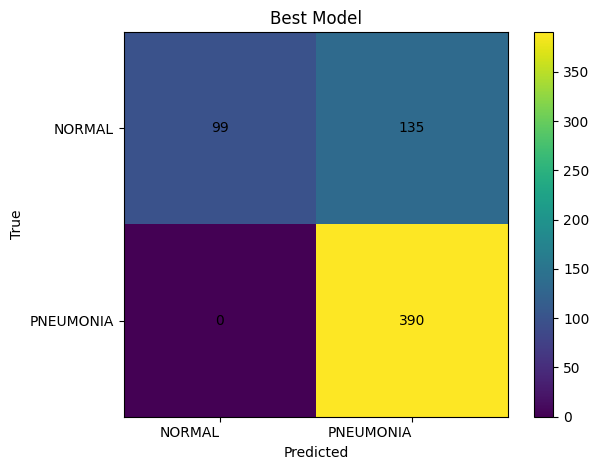

In [27]:
hist_ft_best = fit(model_head, train_loader_resnet, test_loader_resnet, optimizer_ft, criterion, epochs=10, verbose=True)